<a href="https://colab.research.google.com/github/Abdo15P/Fairness-Aware-KMeans/blob/main/ablation-study.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Streaming output truncated to the last 5000 lines.
 
balance measure
No. of Reassignments  693
Skip point
Candidate destinations=====================  4289
 
balance measure
No. of Reassignments  693
Skip point
Candidate destinations=====================  4289
 
balance measure
No. of Reassignments  693
Skip point
Candidate destinations=====================  4289
 
balance measure
No. of Reassignments  693
Skip point
Candidate destinations=====================  4289
 
balance measure
No. of Reassignments  693
Skip point
Candidate destinations=====================  4289
 
balance measure
No. of Reassignments  693
Skip point
Candidate destinations=====================  4289
 
balance measure
No. of Reassignments  693
Skip point
Candidate destinations=====================  4289
 
balance measure
No. of Reassignments  693
Skip point
Candidate destinations=====================  4289
 
balance measure
No. of Reassignments  693
Skip point
Candidate destinations=====================  4289
 
ba

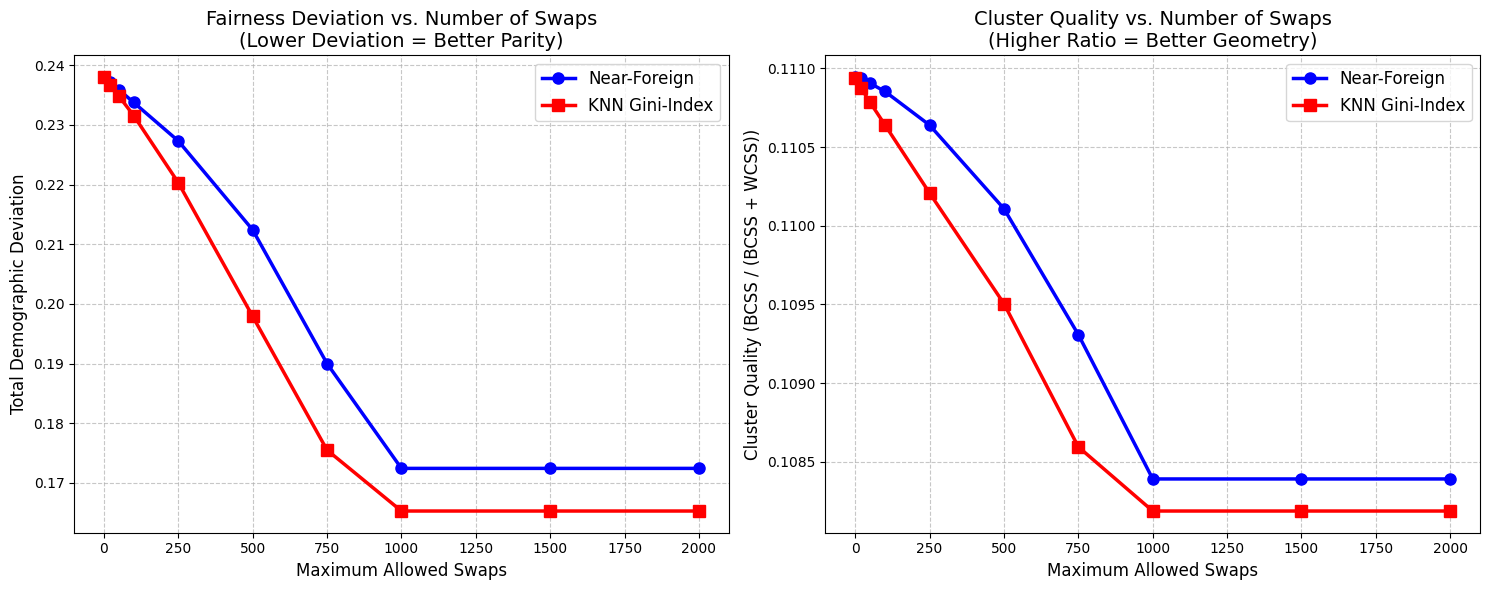

In [ ]:
import matplotlib.pyplot as plt
import copy

def run_ablation_experiments():
    print("======================================================")
    print("1. LOADING DATA & TRAINING BASELINE K-MEANS++")
    print("======================================================")

    # 1. Load Data
    data, sensitive_features, income = preprocessing()

    # 2. Train K-Means Model
    K = 2
    k_means = K_Means(K)
    k_means.fit(data)

    # 3. Get Baseline Predictions
    baseline_labels = np.zeros((data.shape[0],))
    for i in range(data.shape[0]):
        baseline_labels[i] = k_means.predict(data[i])

    print(f"\nBaseline Training Complete. Total data points: {data.shape[0]}")

    print("\n======================================================")
    print("2. STARTING ABLATION STUDY")
    print("======================================================")

    # Define the max_swaps limits we want to test
    swap_limits = [0, 20, 50, 100, 250, 500, 750, 1000,1500,2000]

    # Arrays to store the metrics for graphing
    nf_fairness_scores = []
    nf_cluster_quality = []

    gini_fairness_scores = []
    gini_cluster_quality = []

    for limit in swap_limits:
        print(f"\n\n--- TESTING WITH MAX_SWAPS = {limit} ---")

        # VERY IMPORTANT: Pass a fresh copy of the baseline labels each time
        # so the algorithms start from the exact same physical baseline.
        labels_for_nf = baseline_labels.copy()
        labels_for_gini = baseline_labels.copy()

        # --- Run Near-Foreign ---
        nf_results = near_foreign_reassignment_combined(
            data=data,
            predictions=labels_for_nf,
            sensitive_features=sensitive_features[:, 1], # Using gender as in your main()
            centroids=k_means.centroids,
            k=K,
            max_swaps=limit
        )
        # Append the last_fairness_quality (index 4) and last_cluster_quality (index 2)
        nf_cluster_quality.append(nf_results[2])
        nf_fairness_scores.append(nf_results[4])

        # --- Run Gini-Index ---
        gini_results = gini_index_reassignment_combined(
            data=data,
            predictions=labels_for_gini,
            sensitive_features=sensitive_features[:, 1],
            centroids=k_means.centroids,
            k=K,
            KNN=5, # Your chosen KNN value
            max_swaps=limit
        )
        gini_cluster_quality.append(gini_results[2])
        gini_fairness_scores.append(gini_results[4])
        print(gini_results[6])

    print("\n======================================================")
    print("3. GENERATING ABLATION GRAPHS")
    print("======================================================")

    # Draw the graphs side-by-side
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

    # Graph 1: Fairness Quality vs Swaps
    # Note: Because your fairness score is a sum of absolute deviations, LOWER IS BETTER.
    ax1.plot(swap_limits, nf_fairness_scores, marker='o', label='Near-Foreign', color='blue', linewidth=2.5, markersize=8)
    ax1.plot(swap_limits, gini_fairness_scores, marker='s', label='KNN Gini-Index', color='red', linewidth=2.5, markersize=8)
    ax1.set_title('Fairness Deviation vs. Number of Swaps\n(Lower Deviation = Better Parity)', fontsize=14)
    ax1.set_xlabel('Maximum Allowed Swaps', fontsize=12)
    ax1.set_ylabel('Total Demographic Deviation', fontsize=12)
    ax1.grid(True, linestyle='--', alpha=0.7)
    ax1.legend(fontsize=12)

    # Graph 2: Cluster Quality (BCSS/Total) vs Swaps
    # Note: BCSS ratio approaches 1.0 for highly separated clusters, so HIGHER IS BETTER.
    ax2.plot(swap_limits, nf_cluster_quality, marker='o', label='Near-Foreign', color='blue', linewidth=2.5, markersize=8)
    ax2.plot(swap_limits, gini_cluster_quality, marker='s', label='KNN Gini-Index', color='red', linewidth=2.5, markersize=8)
    ax2.set_title('Cluster Quality vs. Number of Swaps\n(Higher Ratio = Better Geometry)', fontsize=14)
    ax2.set_xlabel('Maximum Allowed Swaps', fontsize=12)
    ax2.set_ylabel('Cluster Quality (BCSS / (BCSS + WCSS))', fontsize=12)
    ax2.grid(True, linestyle='--', alpha=0.7)
    ax2.legend(fontsize=12)

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    run_ablation_experiments()